# 1. Import Libraries

## Objective

Import the libraries required for demonstrating the knowledge decay prediction system.

## Expected Output

Required libraries successfully imported.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_NAME = "Personal Knowledge Decay Predictor"

matches = [
    p for p in Path("/content/drive/MyDrive").rglob(PROJECT_NAME)
    if p.is_dir()
]

PROJECT_ROOT = matches[0]

sys.path.append(str(PROJECT_ROOT))

from config import *

print("✅ Project Root :", PROJECT_ROOT)

✅ Project Root : /content/drive/MyDrive/Marwadi_uiniversity/Personal Knowledge Decay Predictor


In [31]:
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [32]:
best_model = joblib.load(
    f"{MODEL_DIR}/best_model.pkl"
)
scaler = joblib.load(
    MODEL_DIR / "scaler.pkl"
)

print("✅ Model Loaded Successfully")
print("Model Type:", type(best_model))

✅ Model Loaded Successfully
Model Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>


📒 Section 3 — Project Overview
# Knowledge Decay Prediction System

## Objective

Predict whether a student is likely to forget previously learned knowledge.

## Workflow

1. Student interaction history is collected.
2. Historical learning features are engineered.
3. The trained Logistic Regression model predicts forgetting risk.
4. High-risk students receive timely revision recommendations.

This system enables proactive intervention in adaptive learning environments.

📒 Section 4 — Student Prediction Demo

In [33]:
# =====================================================
# Prediction Function
# =====================================================

feature_columns = [
    "interaction_order",
    "past_attempts",
    "past_correct",
    "past_accuracy",
    "rolling_accuracy",
    "mastered"
]

def predict_forgetting(student_features):
    """
    Predict whether a student is at risk of forgetting.
    """

    student_df = pd.DataFrame(
        [student_features],
        columns=feature_columns
    )

    student_scaled = scaler.transform(student_df)

    prediction = best_model.predict(student_scaled)[0]

    probability = best_model.predict_proba(student_scaled)[0][1]

    return prediction, probability

In [34]:
sample_student = [
    12,
    12,
    6,
    0.50,
    0.40,
    1
]

prediction, probability = predict_forgetting(sample_student)

result = pd.DataFrame({
    "Prediction": [
        "High Risk" if prediction == 1 else "Low Risk"
    ],
    "Probability (%)": [
        round(probability * 100, 2)
    ]
})

display(result)

,Prediction,Probability (%)
0,High Risk,70.5


📒 Section 5 — Model Performance Dashboard

In [35]:
comparison = pd.read_csv(
    f"{DATA_DIR}/Processed/model_ready_dataset.csv",
    low_memory=False
)

display(comparison)
print("Dataset Shape :", comparison.shape)

comparison.head()

,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,Ln,MCAS,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered,future_accuracy,forget_event
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.759192485,45,1,0,0.0,0.0,NaN,0,0.789474,0
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.908767782,45,2,1,1.0,1.0,NaN,0,0.777778,0
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.969112157,45,3,2,2.0,1.0,NaN,0,0.764706,0
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.989972799,45,4,3,3.0,1.0,NaN,0,0.750000,0
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.936555224,45,5,4,4.0,1.0,NaN,0,0.800000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871609,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.355561715,28,1,0,0.0,0.0,NaN,0,1.000000,0
871610,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.103132687,28,1,0,0.0,0.0,NaN,0,0.500000,0
871611,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.114464435,28,2,1,0.0,0.0,NaN,0,0.666667,0
871612,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.114464435,28,3,2,0.0,0.0,NaN,0,1.000000,0


Dataset Shape : (871614, 85)


,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,Ln,MCAS,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered,future_accuracy,forget_event
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.759192485,45,1,0,0.0,0.0,NaN,0,0.789474,0
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.908767782,45,2,1,1.0,1.0,NaN,0,0.777778,0
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.969112157,45,3,2,2.0,1.0,NaN,0,0.764706,0
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.989972799,45,4,3,3.0,1.0,NaN,0,0.750000,0
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.936555224,45,5,4,4.0,1.0,NaN,0,0.800000,0


Accuracy Comparison

<Figure size 700x500 with 0 Axes>

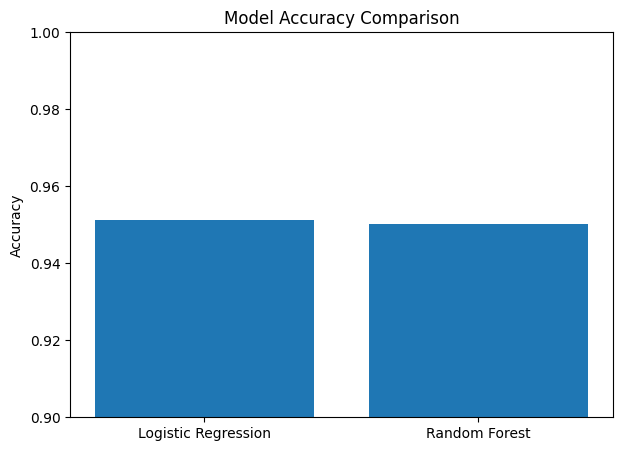

In [36]:
plt.figure(figsize=(7,5))

# Accuracy Comparison

comparison = pd.read_csv(
    RESULT_DIR / "model_comparison.csv"
)


accuracy_row = comparison[comparison["Metric"] == "Accuracy"]

models = ["Logistic Regression", "Random Forest"]
values = accuracy_row.iloc[0, 1:].astype(float).values

plt.figure(figsize=(7,5))

plt.bar(models, values)

plt.ylim(0.90, 1.00)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

ROC-AUC Comparison

<Figure size 700x500 with 0 Axes>

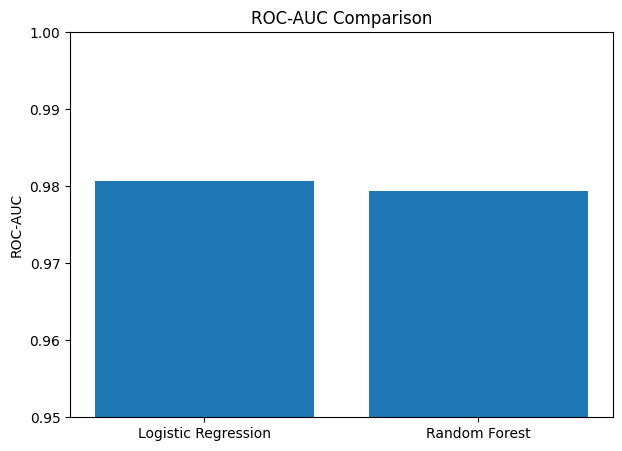

In [37]:
plt.figure(figsize=(7,5))

roc_row = comparison[comparison["Metric"] == "ROC AUC"]

models = ["Logistic Regression", "Random Forest"]
values = roc_row.iloc[0, 1:].astype(float).values

plt.figure(figsize=(7,5))

plt.bar(models, values)

plt.ylim(0.95, 1.00)

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Comparison")

plt.show()

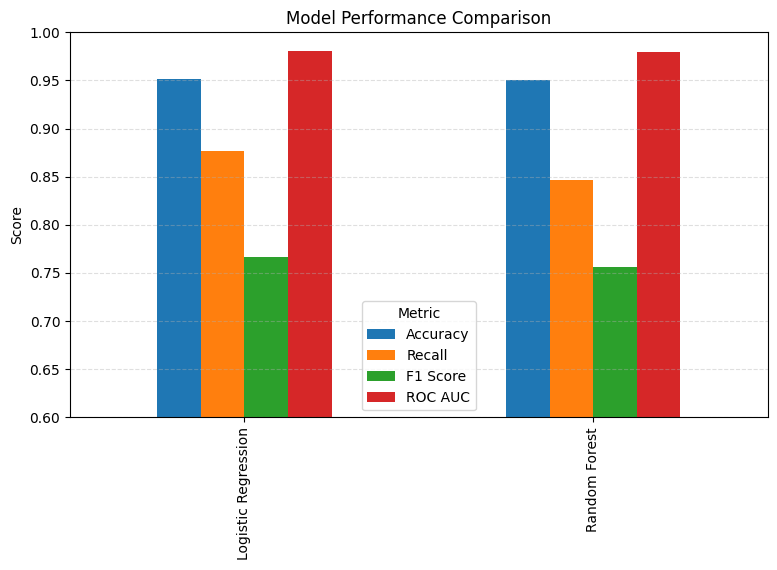

In [38]:
comparison_plot = comparison.set_index("Metric").T

comparison_plot[["Accuracy", "Recall", "F1 Score", "ROC AUC"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

📒 Section 6 — Feature Contribution

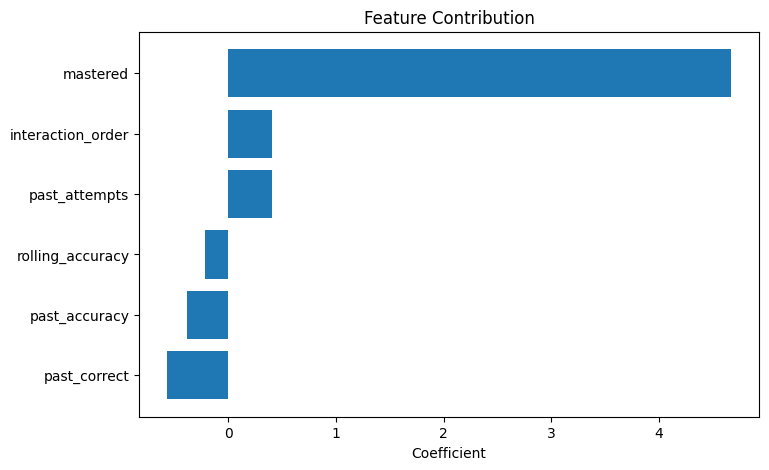

In [39]:
coef_df = pd.DataFrame({
    "Feature":feature_columns,
    "Coefficient":best_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(8,5))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.xlabel("Coefficient")

plt.title("Feature Contribution")

plt.show()

# End-to-End Workflow

```text
Student Interaction History
            │
            ▼
Feature Engineering
            │
            ▼
Historical Learning Features
            │
            ▼
Logistic Regression Model
            │
            ▼
Probability of Forgetting
            │
      ┌─────┴─────┐
      ▼           ▼
 High Risk    Low Risk
      │           │
 Recommend   Continue
 Revision     Learning
```

# Project Conclusion

The proposed knowledge decay prediction system successfully predicts whether a learner is likely to experience future forgetting based on historical learning interactions.

Among the evaluated models, Logistic Regression achieved the best overall performance, with strong Accuracy, Recall, F1-score, and ROC-AUC.

The system demonstrates the feasibility of using machine learning to support adaptive learning environments by identifying learners who may benefit from timely revision.

This approach can be extended in future work with richer learner profiles, additional educational datasets, and real-time deployment.

# Notebook Summary

This notebook demonstrated the complete Knowledge Decay Prediction System.

The following tasks were completed:

- Loaded the trained model
- Predicted forgetting risk for new learners
- Displayed prediction probabilities
- Compared model performance
- Visualized feature contributions
- Presented the end-to-end workflow

The project is now ready for demonstration and presentation.